In [ ]:
#@title 0.1 · Cài đặt thư viện { display-mode: "form" }
!pip install -q torch torchaudio numpy pandas scipy soundfile librosa pyloudnorm matplotlib seaborn tqdm scikit-learn umap-learn
print("Đã cài xong thư viện.")

Đã cài xong thư viện.


In [ ]:
#@title 0.2 · Import & cấu hình (gộp một nơi duy nhất, không định nghĩa lại ở các mục sau) { display-mode: "form" }
import os, json, math, random, warnings, hashlib
from pathlib import Path
from typing import Optional, Dict, Any, List, Tuple
from contextlib import nullcontext

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import soundfile as sf
import librosa
import pyloudnorm as pyln

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
)

try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False

from IPython.display import display, Audio, Markdown

warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

# ---- Đường dẫn (Drive) — CHỈ trỏ tới checkpoint đã đóng băng, không có nơi nào ghi đè ----
DRIVE_ROOT = Path("/content/drive/MyDrive")
PHASE1_CKPT = DRIVE_ROOT / "motionemo_v10_phase1/checkpoints/best_phase1_v10.pt"
PHASE2_CKPT = DRIVE_ROOT / "motionemo_v10_phase2/checkpoints/best_phase2_state.pt"

LOCAL_DATA_ROOT = Path("/content/processed_v10_safe")
DRIVE_DATA_ROOT = DRIVE_ROOT / "data/processed_v10_safe"
DATA_ROOT = LOCAL_DATA_ROOT if (LOCAL_DATA_ROOT / "all_metadata.csv").exists() else DRIVE_DATA_ROOT
METADATA_PATH = DATA_ROOT / "all_metadata.csv"
PRECOMPUTED_DIR = DATA_ROOT / "precomputed"

OUTPUT_ROOT = DRIVE_ROOT / "motionemo_v10_eval_capability"
CACHE_ROOT = OUTPUT_ROOT / "_cache"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP_ENABLED = DEVICE == "cuda"

STATE_NAMES = ["activation", "tension", "stability"]
STATE_DISPLAY_NAMES = {"activation": "Vocal Activation", "tension": "Vocal Tension", "stability": "Vocal Stability"}
STATE_LABEL_NAMES = ["low", "mid", "high"]
STATE_SCORE_LEVELS = np.array([0.0, 0.5, 1.0], dtype=np.float32)

COLORS = dict(activation="#2F80ED", tension="#E76F51", stability="#2A9D8F",
              transition="#7B2CBF", grid="#DEE2E6", text="#212529")

AUDIO_CFG = dict(sample_rate=16000, n_mels=80, n_fft=512, win_length=400, hop_length=160,
                  f_min=50.0, f_max=8000.0, f0_min=50.0, f0_max=500.0, top_db=80.0,
                  target_lufs=-23.0, peak_guard=0.98)

WINDOW_CFG = dict(window_sec=2.5, hop_sec=0.5, min_window_sec=1.2, max_frames=500)

DEMO_CFG = dict(
    reference_split="test", max_reference_samples=1000, reference_random_seed=42, use_umap=True,
    smooth_window=5, use_silence_trim=True,
    high_tension_threshold=0.65, low_stability_threshold=0.35,
    stable_tension_threshold=0.25, stable_stability_threshold=0.70,
    rapid_transition_quantile=0.85,
    max_windows_for_dense_trajectory=70, segment_sec_for_long_audio=5.0,
)

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(42)

def autocast_context():
    if AMP_ENABLED and DEVICE == "cuda":
        return torch.amp.autocast("cuda", enabled=True)
    return nullcontext()

def make_padding_mask(lengths: torch.Tensor, max_len: int) -> torch.Tensor:
    idx = torch.arange(max_len, device=lengths.device).unsqueeze(0)
    return idx >= lengths.unsqueeze(1)

def safe_zscore_np(x: np.ndarray, mask: Optional[np.ndarray] = None, eps: float = 1e-8) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    if x.size == 0: return x.astype(np.float32)
    if mask is not None:
        mask = np.asarray(mask).astype(bool)
        mu, sd = (float(x[mask].mean()), float(x[mask].std())) if mask.sum() > 1 else (float(x.mean()), float(x.std()))
    else:
        mu, sd = float(x.mean()), float(x.std())
    if not np.isfinite(sd) or sd < eps: sd = 1.0
    return ((x - mu) / (sd + eps)).astype(np.float32)

def align_1d_to_T(x: np.ndarray, T: int) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) == T: return x
    if len(x) > T: return x[:T]
    if len(x) == 0: return np.zeros(T, dtype=np.float32)
    return np.concatenate([x, np.full(T - len(x), x[-1], dtype=np.float32)], axis=0)

def savefig(path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    print("Đã lưu:", path)

def safe_filename_stem(path: Path) -> str:
    return Path(path).stem.replace(" ", "_").replace("/", "_").replace("\\", "_")

print("Device:", DEVICE, "| AMP:", AMP_ENABLED, "| UMAP:", UMAP_AVAILABLE)
print("Metadata exists:", METADATA_PATH.exists(), "| Precomputed exists:", PRECOMPUTED_DIR.exists())
print("Output root:", OUTPUT_ROOT)

Mounted at /content/drive
Device: cuda | AMP: True | UMAP: True
Metadata exists: True | Precomputed exists: True
Output root: /content/drive/MyDrive/motionemo_v10_eval_capability


In [ ]:
#@title 0.3 · Kiến trúc model — sao chép NGUYÊN VĂN từ Training_phase1/2, không sửa { display-mode: "form" }
class MotionEmoBackboneV10(nn.Module):
    def __init__(self, n_mels=80, embed_dim=512, num_heads=8, num_layers=6, dropout=0.1):
        super().__init__()
        self.prosody_encoder = nn.Sequential(
            nn.Conv1d(3, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=5, padding=2), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.mel_encoder = nn.Sequential(
            nn.Conv1d(n_mels, 256, kernel_size=5, padding=2), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.fusion_proj = nn.Sequential(nn.Linear(512, embed_dim), nn.LayerNorm(embed_dim))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            dropout=dropout, batch_first=True, norm_first=True, activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.attn_pool = nn.Sequential(nn.Linear(embed_dim, embed_dim // 4), nn.Tanh(), nn.Linear(embed_dim // 4, 1))

    def forward(self, mel, f0, energy, srate, lengths: Optional[torch.Tensor] = None):
        B, _, T = mel.shape
        prosody_in = torch.stack([f0, energy, srate], dim=1)
        p_feat = self.prosody_encoder(prosody_in)
        m_feat = self.mel_encoder(mel)
        fused = torch.cat([p_feat, m_feat], dim=1)
        x = self.fusion_proj(fused.transpose(1, 2))
        pad_mask = make_padding_mask(lengths, T) if lengths is not None else None
        H_frame = self.transformer(x, src_key_padding_mask=pad_mask)
        attn_logits = self.attn_pool(H_frame).squeeze(-1)
        if pad_mask is not None:
            attn_logits = attn_logits.masked_fill(pad_mask, -1e4)
        attn = torch.softmax(attn_logits, dim=1).unsqueeze(-1)
        H_utt = (attn * H_frame).sum(dim=1)
        return H_frame, H_utt

class StateHead(nn.Module):
    def __init__(self, embed_dim=512, hidden_dim=256, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.GELU(), nn.Dropout(0.1), nn.Linear(hidden_dim, num_classes),
        )
    def forward(self, H_utt):
        return self.net(H_utt)
print("Đã định nghĩa MotionEmoBackboneV10 và StateHead (nguyên văn).")

Đã định nghĩa MotionEmoBackboneV10 và StateHead (nguyên văn).


In [ ]:
#@title 0.4 · Nạp checkpoint đã đóng băng + bằng chứng KHÔNG huấn luyện lại { display-mode: "form" }
def checkpoint_fingerprint(path: Path) -> str:
    """Fingerprint nhẹ theo tên/kích thước/thời điểm sửa file — đủ để phát hiện file bị thay."""
    if not path.exists():
        return "missing"
    text = f"{path.name}_{path.stat().st_size}_{int(path.stat().st_mtime)}"
    return hashlib.md5(text.encode("utf-8")).hexdigest()[:10]

def infer_model_config(ckpt: Dict[str, Any]):
    cfg = ckpt.get("cfg", {})
    model_cfg = cfg.get("model", {}) if isinstance(cfg, dict) else {}
    return dict(embed_dim=int(model_cfg.get("embedding_dim", 512)), num_heads=int(model_cfg.get("num_heads", 8)),
                num_layers=int(model_cfg.get("num_layers", 6)), dropout=float(model_cfg.get("dropout", 0.1)),
                state_hidden=int(model_cfg.get("state_hidden", 256)), num_state_classes=int(model_cfg.get("num_state_classes", 3)))

def build_backbone_from_ckpt(ckpt: Dict[str, Any]):
    mc = infer_model_config(ckpt)
    model = MotionEmoBackboneV10(n_mels=AUDIO_CFG["n_mels"], embed_dim=mc["embed_dim"],
                                  num_heads=mc["num_heads"], num_layers=mc["num_layers"], dropout=mc["dropout"]).to(DEVICE)
    model.load_state_dict(ckpt["backbone"], strict=True)
    model.eval()
    return model, mc

if not PHASE2_CKPT.exists():
    raise FileNotFoundError(f"Thiếu checkpoint Phase 2: {PHASE2_CKPT}")
if not PHASE1_CKPT.exists():
    raise FileNotFoundError(f"Thiếu checkpoint Phase 1: {PHASE1_CKPT}")

phase2_ckpt = torch.load(PHASE2_CKPT, map_location=DEVICE, weights_only=False)
phase2_backbone, model_cfg = build_backbone_from_ckpt(phase2_ckpt)

activation_head = StateHead(model_cfg["embed_dim"], model_cfg["state_hidden"], model_cfg["num_state_classes"]).to(DEVICE)
tension_head    = StateHead(model_cfg["embed_dim"], model_cfg["state_hidden"], model_cfg["num_state_classes"]).to(DEVICE)
stability_head  = StateHead(model_cfg["embed_dim"], model_cfg["state_hidden"], model_cfg["num_state_classes"]).to(DEVICE)
activation_head.load_state_dict(phase2_ckpt["activation_head"]); activation_head.eval()
tension_head.load_state_dict(phase2_ckpt["tension_head"]);       tension_head.eval()
stability_head.load_state_dict(phase2_ckpt["stability_head"]);   stability_head.eval()

# state_thresholds dùng để gán nhãn proxy PHẢI lấy từ chính checkpoint đã train,
# KHÔNG tính lại — tránh lệch ngưỡng so với lúc huấn luyện.
STATE_THRESHOLDS = phase2_ckpt.get("state_thresholds")
if STATE_THRESHOLDS is None:
    raise RuntimeError("Checkpoint Phase 2 không có 'state_thresholds' — không thể đánh giá nhất quán với lúc train.")

phase1_ckpt = torch.load(PHASE1_CKPT, map_location=DEVICE, weights_only=False)
phase1_backbone, _ = build_backbone_from_ckpt(phase1_ckpt)

print("=" * 70)
print("BẰNG CHỨNG KHÔNG HUẤN LUYỆN LẠI — fingerprint + thông số đã ghi nhận lúc train")
print("=" * 70)
print(f"Phase 1 checkpoint : {PHASE1_CKPT}")
print(f"  fingerprint = {checkpoint_fingerprint(PHASE1_CKPT)}")
print(f"Phase 2 checkpoint : {PHASE2_CKPT}")
print(f"  fingerprint = {checkpoint_fingerprint(PHASE2_CKPT)}")
print(f"  epoch = {phase2_ckpt.get('epoch')} | best_val_loss = {phase2_ckpt.get('best_val_loss')} | "
      f"best_state_acc = {phase2_ckpt.get('best_state_acc')}")
print(f"  state_thresholds (nạp từ checkpoint, không tính lại) = {json.dumps(STATE_THRESHOLDS, indent=2)}")
print("\nNếu chạy lại notebook này vào thời điểm khác mà các số trên không đổi,")
print("tức là đang dùng đúng một checkpoint, không có huấn luyện lại xảy ra.")

BẰNG CHỨNG KHÔNG HUẤN LUYỆN LẠI — fingerprint + thông số đã ghi nhận lúc train
Phase 1 checkpoint : /content/drive/MyDrive/motionemo_v10_phase1/checkpoints/best_phase1_v10.pt
  fingerprint = bb941e3d94
Phase 2 checkpoint : /content/drive/MyDrive/motionemo_v10_phase2/checkpoints/best_phase2_state.pt
  fingerprint = 811a04d02e
  epoch = 25 | best_val_loss = 0.8443085433842542 | best_state_acc = 0.868068068068068
  state_thresholds (nạp từ checkpoint, không tính lại) = {
  "activation": [
    -1.1789047548920202,
    -1.0910444258413774
  ],
  "tension": [
    0.5080785265271103,
    0.608056457961331
  ],
  "stability": [
    -0.41222898640634226,
    -0.33455883524576263
  ]
}

Nếu chạy lại notebook này vào thời điểm khác mà các số trên không đổi,
tức là đang dùng đúng một checkpoint, không có huấn luyện lại xảy ra.


In [ ]:
#@title 1.1 · Hàm tính nhãn proxy + Dataset — sao chép NGUYÊN VĂN từ Training_phase2 { display-mode: "form" }
def _to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def compute_vocal_state_scores_from_arrays(f0_raw, energy_raw, zcr_raw, voiced_mask) -> Dict[str, float]:
    """Tính điểm proxy liên tục Activation/Tension/Stability từ đặc trưng KHUNG THÔ (chưa chuẩn hóa).
    Đây không phải nhãn tâm lý — là proxy âm học yếu, dùng để neo biểu diễn vào động học giọng nói."""
    f0 = _to_np(f0_raw).astype(np.float32).reshape(-1)
    energy = _to_np(energy_raw).astype(np.float32).reshape(-1)
    zcr = _to_np(zcr_raw).astype(np.float32).reshape(-1)
    voiced = _to_np(voiced_mask).astype(np.float32).reshape(-1) > 0.5

    T = min(len(f0), len(energy), len(zcr), len(voiced))
    if T <= 2:
        return {"activation": 0.0, "tension": 0.0, "stability": 0.0}

    f0 = f0[:T]
    energy = np.maximum(energy[:T], 0.0)
    zcr = np.maximum(zcr[:T], 0.0)
    voiced = voiced[:T] & np.isfinite(f0) & (f0 > 0)
    eps = 1e-8

    e_mean = float(np.mean(energy)); e_std = float(np.std(energy))
    e_p95 = float(np.percentile(energy, 95)) + eps
    e_cv = e_std / (e_mean + eps)
    e_rel = energy / e_p95
    pause_ratio = float(np.mean(e_rel < 0.03))

    z_mean = float(np.mean(zcr)); z_std = float(np.std(zcr))

    if voiced.sum() > 2:
        vf0 = f0[voiced]
        f0_mean = float(np.mean(vf0)) + eps
        f0_p10 = float(np.percentile(vf0, 10)); f0_p90 = float(np.percentile(vf0, 90))
        f0_range_rel = (f0_p90 - f0_p10) / f0_mean
        f0_diff = np.diff(vf0)
        f0_motion_rel = float(np.std(f0_diff)) / f0_mean
    else:
        f0_range_rel = 0.0; f0_motion_rel = 0.0

    log_energy = math.log(e_mean + 1e-6)
    activation = 0.45 * log_energy + 0.35 * z_mean + 0.20 * f0_range_rel
    tension = 0.45 * f0_motion_rel + 0.35 * e_cv + 0.20 * z_std
    instability = 0.45 * pause_ratio + 0.35 * f0_motion_rel + 0.20 * e_cv
    stability = -instability

    return {"activation": float(activation), "tension": float(tension), "stability": float(stability)}

def assign_state_label(score: float, thresholds: List[float]) -> int:
    lo, hi = thresholds
    if score <= lo: return 0
    if score <= hi: return 1
    return 2

class Phase2StateDataset(Dataset):
    """Sao chép nguyên văn từ Training_phase2.ipynb (đã đóng băng)."""
    def __init__(self, df_data: pd.DataFrame, thresholds: Dict[str, Any], max_frames: int = 500, deterministic_crop: bool = False):
        self.df = df_data.reset_index(drop=True)
        self.thresholds = thresholds
        self.max_frames = max_frames
        self.deterministic_crop = deterministic_crop

    def __len__(self):
        return len(self.df)

    def _crop_start(self, T: int) -> int:
        if T <= self.max_frames: return 0
        if self.deterministic_crop: return max(0, (T - self.max_frames) // 2)
        return random.randint(0, T - self.max_frames)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.df.iloc[idx]
        path = Path(row["feature_path"])
        obj = torch.load(path, map_location="cpu", weights_only=False)

        mel = obj["mel"].float(); f0 = obj["f0"].float()
        energy = obj["energy"].float(); srate = obj["speaking_rate"].float()
        f0_raw = obj["f0_raw"].float(); energy_raw = obj["energy_raw"].float()
        zcr_raw = obj["zcr_raw"].float(); voiced_mask = obj["voiced_mask"].float()

        T = mel.shape[1]
        if T > self.max_frames:
            start = self._crop_start(T); end = start + self.max_frames
            mel = mel[:, start:end]; f0 = f0[start:end]; energy = energy[start:end]; srate = srate[start:end]
            f0_raw = f0_raw[start:end]; energy_raw = energy_raw[start:end]
            zcr_raw = zcr_raw[start:end]; voiced_mask = voiced_mask[start:end]

        scores = compute_vocal_state_scores_from_arrays(f0_raw, energy_raw, zcr_raw, voiced_mask)
        activation_label = assign_state_label(scores["activation"], self.thresholds["activation"])
        tension_label = assign_state_label(scores["tension"], self.thresholds["tension"])
        stability_label = assign_state_label(scores["stability"], self.thresholds["stability"])

        return dict(mel=mel, f0=f0, energy=energy, srate=srate, length=mel.shape[1],
                    activation_label=activation_label, tension_label=tension_label, stability_label=stability_label,
                    sample_id=row["sample_id"], dataset=row["dataset"])

def collate_state_fn(batch):
    max_len = max(item["length"] for item in batch)
    mels, f0s, energies, srates, lengths = [], [], [], [], []
    act, ten, sta, sample_ids, datasets = [], [], [], [], []
    for item in batch:
        pad = max_len - item["length"]
        mels.append(F.pad(item["mel"], (0, pad)).unsqueeze(0))
        f0s.append(F.pad(item["f0"], (0, pad)).unsqueeze(0))
        energies.append(F.pad(item["energy"], (0, pad)).unsqueeze(0))
        srates.append(F.pad(item["srate"], (0, pad)).unsqueeze(0))
        lengths.append(item["length"])
        act.append(item["activation_label"]); ten.append(item["tension_label"]); sta.append(item["stability_label"])
        sample_ids.append(item["sample_id"]); datasets.append(item["dataset"])
    return dict(
        mel=torch.cat(mels, dim=0), f0=torch.cat(f0s, dim=0), energy=torch.cat(energies, dim=0), srate=torch.cat(srates, dim=0),
        lengths=torch.tensor(lengths, dtype=torch.long),
        activation_label=torch.tensor(act, dtype=torch.long), tension_label=torch.tensor(ten, dtype=torch.long),
        stability_label=torch.tensor(sta, dtype=torch.long), sample_id=sample_ids, dataset=datasets,
    )
print("Đã định nghĩa hàm nhãn proxy + Phase2StateDataset (nguyên văn từ Training_phase2).")

Đã định nghĩa hàm nhãn proxy + Phase2StateDataset (nguyên văn từ Training_phase2).


In [ ]:
#@title 1.2 · Nạp metadata, dựng loader VAL/TEST đầy đủ { display-mode: "form" }
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Thiếu metadata: {METADATA_PATH}")

df_meta = pd.read_csv(METADATA_PATH)
df_meta["feature_path"] = df_meta["feature_path"].apply(lambda p: str(PRECOMPUTED_DIR / Path(str(p)).name))
df_meta = df_meta[df_meta["feature_path"].apply(lambda p: Path(p).exists())].copy()

val_df = df_meta[df_meta["split"] == "val"].reset_index(drop=True)
test_df = df_meta[df_meta["split"] == "test"].reset_index(drop=True)

val_eval_ds = Phase2StateDataset(val_df, STATE_THRESHOLDS, max_frames=WINDOW_CFG["max_frames"], deterministic_crop=True)
test_eval_ds = Phase2StateDataset(test_df, STATE_THRESHOLDS, max_frames=WINDOW_CFG["max_frames"], deterministic_crop=True)

loader_kwargs = dict(num_workers=2, pin_memory=(DEVICE == "cuda"))
val_eval_loader = DataLoader(val_eval_ds, batch_size=16, shuffle=False, collate_fn=collate_state_fn, **loader_kwargs)
test_eval_loader = DataLoader(test_eval_ds, batch_size=16, shuffle=False, collate_fn=collate_state_fn, **loader_kwargs)

print(f"VAL: {len(val_eval_ds)} mẫu, {len(val_eval_loader)} batch")
print(f"TEST: {len(test_eval_ds)} mẫu, {len(test_eval_loader)} batch")

VAL: 1665 mẫu, 105 batch
TEST: 1651 mẫu, 104 batch


In [ ]:
#@title 1.3 · Suy luận: nhãn dự đoán + embedding (dùng lại cho phần Kiểm tra đại diện) { display-mode: "form" }
@torch.no_grad()
def extract_state_predictions(loader, split_name="test", collect_embeddings=False):
    y_true = {s: [] for s in STATE_NAMES}
    y_pred = {s: [] for s in STATE_NAMES}
    score_cont = {s: [] for s in STATE_NAMES}
    sample_ids, datasets, embs = [], [], []

    for batch in tqdm(loader, desc=f"Suy luận {split_name}"):
        mel = batch["mel"].to(DEVICE); f0 = batch["f0"].to(DEVICE)
        energy = batch["energy"].to(DEVICE); srate = batch["srate"].to(DEVICE)
        lengths = batch["lengths"].to(DEVICE)

        with autocast_context():
            _, h = phase2_backbone(mel, f0, energy, srate, lengths=lengths)
            act_logits = activation_head(h); ten_logits = tension_head(h); sta_logits = stability_head(h)
            ap = F.softmax(act_logits, dim=-1); tp = F.softmax(ten_logits, dim=-1); sp = F.softmax(sta_logits, dim=-1)

        a_np, t_np, s_np = ap.float().cpu().numpy(), tp.float().cpu().numpy(), sp.float().cpu().numpy()

        y_true["activation"].extend(batch["activation_label"].numpy().tolist())
        y_true["tension"].extend(batch["tension_label"].numpy().tolist())
        y_true["stability"].extend(batch["stability_label"].numpy().tolist())
        y_pred["activation"].extend(a_np.argmax(axis=-1).tolist())
        y_pred["tension"].extend(t_np.argmax(axis=-1).tolist())
        y_pred["stability"].extend(s_np.argmax(axis=-1).tolist())
        score_cont["activation"].extend((a_np * STATE_SCORE_LEVELS).sum(axis=-1).tolist())
        score_cont["tension"].extend((t_np * STATE_SCORE_LEVELS).sum(axis=-1).tolist())
        score_cont["stability"].extend((s_np * STATE_SCORE_LEVELS).sum(axis=-1).tolist())

        sample_ids.extend(batch["sample_id"]); datasets.extend(batch["dataset"])
        if collect_embeddings:
            embs.append(h.float().cpu().numpy())

    for s in STATE_NAMES:
        y_true[s] = np.array(y_true[s], dtype=np.int64)
        y_pred[s] = np.array(y_pred[s], dtype=np.int64)

    out = dict(y_true=y_true, y_pred=y_pred, score_cont=score_cont, sample_id=sample_ids, dataset=datasets)
    if collect_embeddings:
        out["embs"] = np.concatenate(embs, axis=0)
    return out

val_out = extract_state_predictions(val_eval_loader, "val", collect_embeddings=False)
# TEST cần thu thêm embedding H_utt để tái dùng ở mục "Kiểm tra tính đại diện" phía sau,
# tránh phải chạy lại một lượt suy luận riêng chỉ để lấy embedding.
test_out = extract_state_predictions(test_eval_loader, "test", collect_embeddings=True)

print("VAL embeddings: không thu thập (không cần cho các mục sau).")
print("TEST embeddings:", test_out["embs"].shape)

Suy luận val:   0%|          | 0/105 [00:00<?, ?it/s]

Suy luận test:   0%|          | 0/104 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fbab5f83ba0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fbab5f83ba0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

VAL embeddings: không thu thập (không cần cho các mục sau).
TEST embeddings: (1651, 512)


VAL — activation
              precision    recall  f1-score   support

         low     0.8465    0.8878    0.8667       615
         mid     0.7103    0.7160    0.7131       493
        high     0.9044    0.8492    0.8759       557

    accuracy                         0.8240      1665
   macro avg     0.8204    0.8177    0.8186      1665
weighted avg     0.8255    0.8240    0.8243      1665

Đã lưu: /content/drive/MyDrive/motionemo_v10_eval_capability/state_confusion_val_activation.png


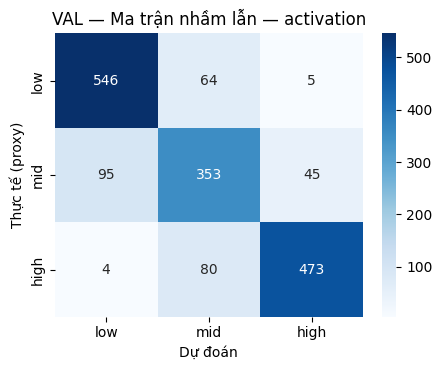

VAL — tension
              precision    recall  f1-score   support

         low     0.9350    0.9350    0.9350       477
         mid     0.8696    0.8318    0.8502       529
        high     0.9150    0.9469    0.9306       659

    accuracy                         0.9069      1665
   macro avg     0.9065    0.9046    0.9053      1665
weighted avg     0.9063    0.9069    0.9064      1665

Đã lưu: /content/drive/MyDrive/motionemo_v10_eval_capability/state_confusion_val_tension.png


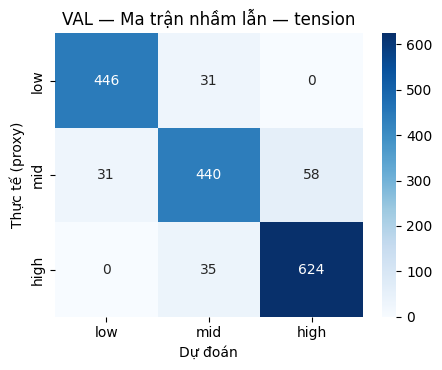

VAL — stability
              precision    recall  f1-score   support

         low     0.9094    0.9294    0.9193       637
         mid     0.7919    0.8346    0.8127       538
        high     0.9329    0.8510    0.8901       490

    accuracy                         0.8757      1665
   macro avg     0.8780    0.8716    0.8740      1665
weighted avg     0.8783    0.8757    0.8762      1665

Đã lưu: /content/drive/MyDrive/motionemo_v10_eval_capability/state_confusion_val_stability.png


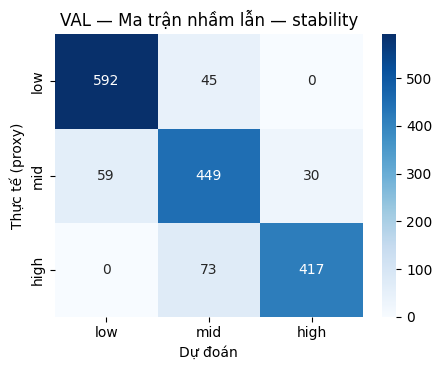

TEST — activation
              precision    recall  f1-score   support

         low     0.8313    0.8958    0.8624       528
         mid     0.7368    0.7642    0.7502       564
        high     0.9155    0.8140    0.8617       559

    accuracy                         0.8231      1651
   macro avg     0.8278    0.8247    0.8248      1651
weighted avg     0.8275    0.8231    0.8238      1651

Đã lưu: /content/drive/MyDrive/motionemo_v10_eval_capability/state_confusion_test_activation.png


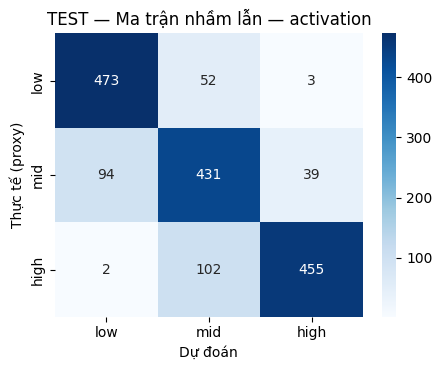

TEST — tension
              precision    recall  f1-score   support

         low     0.9422    0.9214    0.9317       725
         mid     0.8483    0.8053    0.8262       493
        high     0.8840    0.9677    0.9239       433

    accuracy                         0.8988      1651
   macro avg     0.8915    0.8981    0.8939      1651
weighted avg     0.8989    0.8988    0.8981      1651

Đã lưu: /content/drive/MyDrive/motionemo_v10_eval_capability/state_confusion_test_tension.png


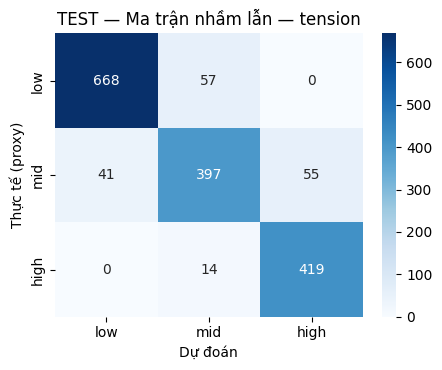

TEST — stability
              precision    recall  f1-score   support

         low     0.8876    0.9165    0.9018       431
         mid     0.7652    0.8364    0.7992       483
        high     0.9558    0.8792    0.9159       737

    accuracy                         0.8764      1651
   macro avg     0.8695    0.8774    0.8723      1651
weighted avg     0.8822    0.8764    0.8781      1651

Đã lưu: /content/drive/MyDrive/motionemo_v10_eval_capability/state_confusion_test_stability.png


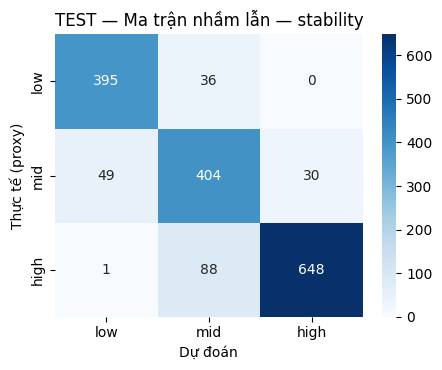

,split,state,accuracy,balanced_accuracy,f1_macro,f1_weighted,n
0,val,activation,0.824024,0.817674,0.818575,0.824303,1665
1,val,tension,0.906907,0.904553,0.905300,0.906352,1665
2,val,stability,0.875676,0.871650,0.874000,0.876227,1665
3,test,activation,0.823137,0.824657,0.824771,0.823839,1651
4,test,tension,0.898849,0.898107,0.893936,0.898147,1651
5,test,stability,0.876439,0.877384,0.872312,0.878088,1651



Trung bình theo split:


,accuracy,balanced_accuracy,f1_macro,f1_weighted
split,,,,
test,0.866142,0.866716,0.863673,0.866692
val,0.868869,0.864625,0.865958,0.868961


In [ ]:
#@title 1.4 · Metric phân loại + ma trận nhầm lẫn { display-mode: "form" }
def evaluate_state_metrics(out, split_name="test", save_confusion=True):
    rows = []
    for state in STATE_NAMES:
        yt, yp = out["y_true"][state], out["y_pred"][state]
        rows.append(dict(
            split=split_name, state=state,
            accuracy=accuracy_score(yt, yp),
            balanced_accuracy=balanced_accuracy_score(yt, yp),
            f1_macro=f1_score(yt, yp, average="macro"),
            f1_weighted=f1_score(yt, yp, average="weighted"),
            n=len(yt),
        ))
        print("=" * 60)
        print(f"{split_name.upper()} — {state}")
        print(classification_report(yt, yp, labels=[0, 1, 2], target_names=STATE_LABEL_NAMES, digits=4, zero_division=0))

        if save_confusion:
            cm = confusion_matrix(yt, yp, labels=[0, 1, 2])
            plt.figure(figsize=(4.6, 3.8))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=STATE_LABEL_NAMES, yticklabels=STATE_LABEL_NAMES)
            plt.xlabel("Dự đoán"); plt.ylabel("Thực tế (proxy)")
            plt.title(f"{split_name.upper()} — Ma trận nhầm lẫn — {state}")
            plt.tight_layout()
            savefig(OUTPUT_ROOT / f"state_confusion_{split_name}_{state}.png")
            plt.show()
    return pd.DataFrame(rows)

val_metrics = evaluate_state_metrics(val_out, "val")
test_metrics = evaluate_state_metrics(test_out, "test")
state_metrics_df = pd.concat([val_metrics, test_metrics], ignore_index=True)
state_metrics_df.to_csv(OUTPUT_ROOT / "state_metrics.csv", index=False)
display(state_metrics_df)

print("\nTrung bình theo split:")
display(state_metrics_df.groupby("split")[["accuracy", "balanced_accuracy", "f1_macro", "f1_weighted"]].mean())

In [ ]:
#@title 2.1 · Dataset đặc trưng thô + trích biểu diễn tham chiếu (1.000 mẫu) { display-mode: "form" }
class PrecomputedFeatureDataset(Dataset):
    """Đọc cả nhánh chuẩn hóa (đầu vào model) lẫn nhánh thô (đặc trưng thủ công, raw baseline)."""
    def __init__(self, df: pd.DataFrame, max_frames: int = 500):
        self.df = df.reset_index(drop=True)
        self.max_frames = max_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        obj = torch.load(row["feature_path"], map_location="cpu", weights_only=False)

        mel = obj["mel"].float(); f0 = obj["f0"].float(); energy = obj["energy"].float()
        srate = obj["speaking_rate"].float() if "speaking_rate" in obj else obj.get("zcr", obj["energy"]).float()
        f0_raw = obj.get("f0_raw", f0).float()
        energy_raw = obj.get("energy_raw", obj.get("mel_abs_db", energy)).float()
        zcr_raw = obj.get("zcr_raw", obj.get("zcr", srate)).float()
        voiced_mask = obj.get("voiced_mask", (f0_raw > 1e-6).float()).float()

        T = mel.shape[1]
        if T > self.max_frames:
            start = max(0, (T - self.max_frames) // 2); end = start + self.max_frames
            mel = mel[:, start:end]; f0 = f0[start:end]; energy = energy[start:end]; srate = srate[start:end]
            f0_raw = f0_raw[start:end]; energy_raw = energy_raw[start:end]
            zcr_raw = zcr_raw[start:end]; voiced_mask = voiced_mask[start:end]

        return dict(mel=mel, f0=f0, energy=energy, srate=srate,
                    f0_raw=f0_raw, energy_raw=energy_raw, zcr_raw=zcr_raw, voiced_mask=voiced_mask,
                    length=mel.shape[1], sample_id=row["sample_id"], dataset=row["dataset"],
                    emotion=row["emotion"], emotion_label=int(row["emotion_label"]),
                    speaker_uid=row.get("speaker_uid", "unknown"), duration_final=float(row.get("duration_final", np.nan)))

def collate_precomputed(batch):
    max_len = max(x["length"] for x in batch)
    tensor_keys = ["mel", "f0", "energy", "srate", "f0_raw", "energy_raw", "zcr_raw", "voiced_mask"]
    out = {k: [] for k in tensor_keys}
    meta = {k: [] for k in ["sample_id", "dataset", "emotion", "emotion_label", "speaker_uid", "duration_final"]}
    lengths = []
    for item in batch:
        pad = max_len - item["length"]
        for k in tensor_keys:
            out[k].append(F.pad(item[k], (0, pad)).unsqueeze(0))
        lengths.append(item["length"])
        for k in meta:
            meta[k].append(item[k])
    batch_out = {k: torch.cat(v, dim=0) for k, v in out.items()}
    batch_out["lengths"] = torch.tensor(lengths, dtype=torch.long)
    batch_out.update(meta)
    return batch_out

def _safe_stats(x: np.ndarray) -> List[float]:
    x = np.nan_to_num(np.asarray(x, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    if x.size == 0: return [0.0] * 5
    return [float(np.mean(x)), float(np.std(x)), float(np.percentile(x, 5)), float(np.percentile(x, 50)), float(np.percentile(x, 95))]

def raw_vector_from_batch(batch: Dict[str, Any]) -> np.ndarray:
    """Đặc trưng thủ công từ tín hiệu thô — KHÔNG phải input chuẩn hóa của model, dùng làm baseline so sánh."""
    f0_raw = batch["f0_raw"].numpy(); energy_raw = batch["energy_raw"].numpy(); zcr_raw = batch["zcr_raw"].numpy()
    voiced_mask = batch["voiced_mask"].numpy() > 0.5
    lengths = batch["lengths"].numpy()
    rows = []
    for i, L in enumerate(lengths):
        e = energy_raw[i, :L]; z = zcr_raw[i, :L]; vmask = voiced_mask[i, :L]; f = f0_raw[i, :L]
        f_voiced = f[vmask & np.isfinite(f) & (f > 0)]
        de = np.diff(e) if len(e) > 1 else np.array([0.0])
        dz = np.diff(z) if len(z) > 1 else np.array([0.0])
        df0 = np.diff(f_voiced) if len(f_voiced) > 1 else np.array([0.0])
        row = _safe_stats(e) + _safe_stats(de) + _safe_stats(z) + _safe_stats(dz) + _safe_stats(f_voiced) + _safe_stats(df0)
        row += [float(vmask.mean()) if L > 0 else 0.0, float(L),
                float(np.max(e) - np.min(e)) if len(e) else 0.0,
                float(np.max(f_voiced) - np.min(f_voiced)) if len(f_voiced) else 0.0]
        rows.append(row)
    return np.asarray(rows, dtype=np.float32)

@torch.no_grad()
def extract_reference_representations(ref_df: pd.DataFrame):
    cache_tag = (f"split{DEMO_CFG['reference_split']}_n{len(ref_df)}_seed{DEMO_CFG['reference_random_seed']}"
                 f"_p1{checkpoint_fingerprint(PHASE1_CKPT)}_p2{checkpoint_fingerprint(PHASE2_CKPT)}")
    cache_npz = CACHE_ROOT / f"reference_representations_{cache_tag}.npz"
    cache_csv = CACHE_ROOT / f"reference_meta_{cache_tag}.csv"
    if cache_npz.exists() and cache_csv.exists():
        print("Nạp từ cache:", cache_npz)
        data = np.load(cache_npz)
        return dict(raw=data["raw"], phase1=data["phase1"] if "phase1" in data.files else None,
                    phase2=data["phase2"], meta=pd.read_csv(cache_csv))

    ds = PrecomputedFeatureDataset(ref_df, max_frames=WINDOW_CFG["max_frames"])
    loader = DataLoader(ds, batch_size=32, shuffle=False, collate_fn=collate_precomputed, num_workers=2, pin_memory=(DEVICE == "cuda"))
    raw_list, p1_list, p2_list, meta_rows = [], [], [], []

    for batch in tqdm(loader, desc="Trích biểu diễn tham chiếu"):
        raw_list.append(raw_vector_from_batch(batch))
        mel = batch["mel"].to(DEVICE); f0 = batch["f0"].to(DEVICE)
        energy = batch["energy"].to(DEVICE); srate = batch["srate"].to(DEVICE); lengths = batch["lengths"].to(DEVICE)

        with autocast_context():
            _, h1 = phase1_backbone(mel, f0, energy, srate, lengths=lengths)
        p1_list.append(h1.float().cpu().numpy())

        with autocast_context():
            _, h2 = phase2_backbone(mel, f0, energy, srate, lengths=lengths)
            ap = F.softmax(activation_head(h2), dim=-1); tp = F.softmax(tension_head(h2), dim=-1); sp = F.softmax(stability_head(h2), dim=-1)
        p2_list.append(h2.float().cpu().numpy())

        ap_np, tp_np, sp_np = ap.float().cpu().numpy(), tp.float().cpu().numpy(), sp.float().cpu().numpy()
        act_score = (ap_np * STATE_SCORE_LEVELS).sum(axis=1)
        ten_score = (tp_np * STATE_SCORE_LEVELS).sum(axis=1)
        sta_score = (sp_np * STATE_SCORE_LEVELS).sum(axis=1)

        for i in range(len(batch["sample_id"])):
            meta_rows.append(dict(
                sample_id=batch["sample_id"][i], dataset=batch["dataset"][i], emotion=batch["emotion"][i],
                emotion_label=batch["emotion_label"][i], speaker_uid=batch["speaker_uid"][i],
                duration_final=batch["duration_final"][i],
                activation_score=float(act_score[i]), tension_score=float(ten_score[i]), stability_score=float(sta_score[i]),
                state_salience=float((act_score[i] + ten_score[i] + (1.0 - sta_score[i])) / 3.0),
            ))

    raw = np.concatenate(raw_list, axis=0); phase1 = np.concatenate(p1_list, axis=0); phase2 = np.concatenate(p2_list, axis=0)
    meta = pd.DataFrame(meta_rows)
    np.savez_compressed(cache_npz, raw=raw, phase1=phase1, phase2=phase2)
    meta.to_csv(cache_csv, index=False)
    print("Đã lưu cache:", cache_npz)
    return dict(raw=raw, phase1=phase1, phase2=phase2, meta=meta)

ref_df = df_meta[df_meta["split"] == DEMO_CFG["reference_split"]].copy().reset_index(drop=True)
if len(ref_df) > DEMO_CFG["max_reference_samples"]:
    ref_df = ref_df.sample(DEMO_CFG["max_reference_samples"], random_state=DEMO_CFG["reference_random_seed"]).reset_index(drop=True)
ref_df["speaker_uid"] = ref_df.get("speaker_uid", "unknown")

print("Tập tham chiếu:", DEMO_CFG["reference_split"], "| số mẫu:", len(ref_df))
reps = extract_reference_representations(ref_df)
ref_meta_rep = reps["meta"]
print("Raw shape:", reps["raw"].shape, "| Phase1 shape:", reps["phase1"].shape, "| Phase2 shape:", reps["phase2"].shape)
display(ref_meta_rep.head())

Tập tham chiếu: test | số mẫu: 1000
Nạp từ cache: /content/drive/MyDrive/motionemo_v10_eval_capability/_cache/reference_representations_splittest_n1000_seed42_p1bb941e3d94_p2811a04d02e.npz
Raw shape: (1000, 34) | Phase1 shape: (1000, 512) | Phase2 shape: (1000, 512)


,sample_id,dataset,emotion,emotion_label,speaker_uid,duration_final,activation_score,tension_score,stability_score,state_salience
0,iemocap__831dc57194b1__Ses05M_impro07_M004,iemocap,happiness,2,iemocap__Ses05M,3.36,0.613972,0.438699,0.410891,0.547260
1,iemocap__a88ceb69aa50__Ses02F_impro03_M024,iemocap,happiness,2,iemocap__Ses02F,4.25,0.605491,0.000341,0.999030,0.202267
2,crema__690a5f953ac5__1033_ITH_ANG_XX,crema,anger,0,crema__speaker_1033,2.76,0.000920,0.999500,0.000637,0.666594
3,iemocap__3cac56f17faa__Ses05M_impro07_M003,iemocap,happiness,2,iemocap__Ses05M,2.35,0.883050,0.014637,0.907030,0.330219
4,iemocap__917c2d079942__Ses02F_impro02_F012,iemocap,sadness,4,iemocap__Ses02F,6.28,0.496520,0.014101,0.988753,0.173956


Đã lưu: /content/drive/MyDrive/motionemo_v10_eval_capability/capability_A_representation_evolution.png


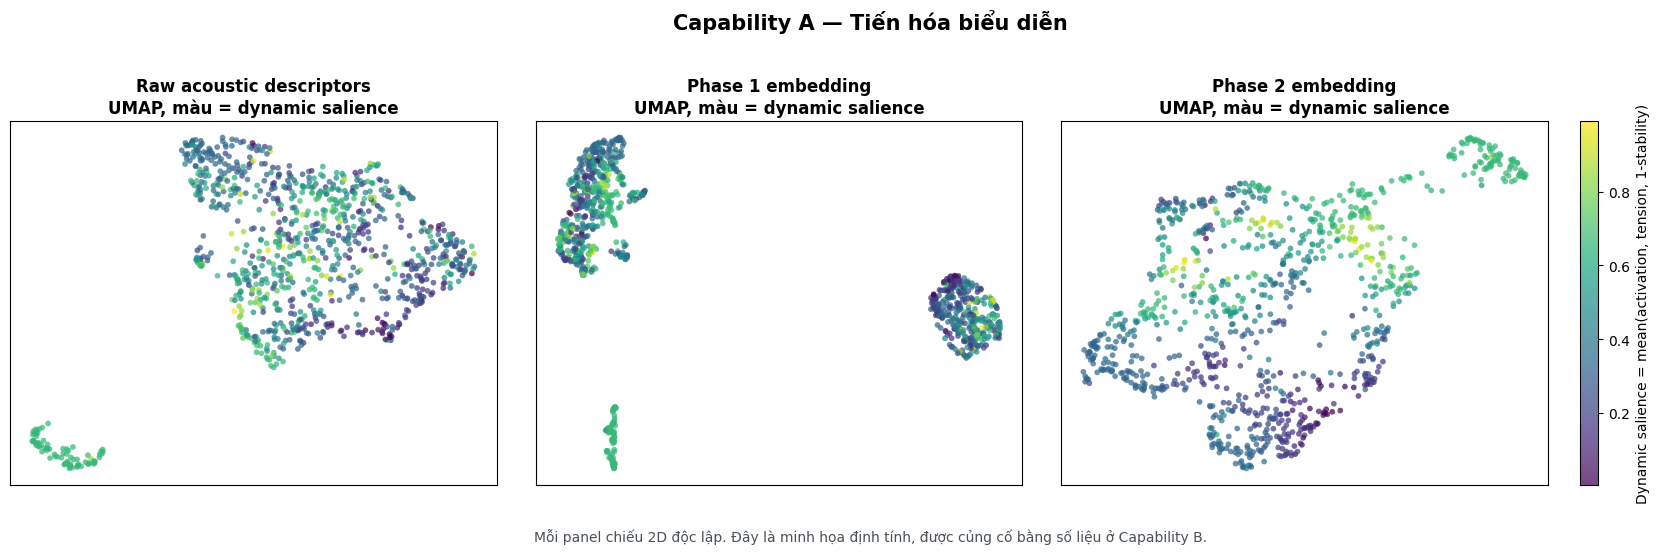

Bản tô theo speaker_uid sẽ được tạo và hiển thị ở mục Hạn chế (dùng lại `reps`, không trích biểu diễn lại).


In [ ]:
#@title 2.2 · UMAP chính thức + bản backup speaker_uid { display-mode: "form" }
def project_2d(X: np.ndarray, title: str, random_state: int = 42):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[1] <= 64:
        Xn = StandardScaler().fit_transform(X); metric = "euclidean"
    else:
        Xn = Normalizer(norm="l2").fit_transform(X); metric = "cosine"
    if DEMO_CFG["use_umap"] and UMAP_AVAILABLE:
        reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.12, metric=metric, random_state=random_state)
        return reducer.fit_transform(Xn), reducer, "UMAP"
    reducer = PCA(n_components=2, random_state=random_state)
    return reducer.fit_transform(Xn), reducer, "PCA"

def plot_representation_evolution(reps, meta):
    panels = [("Raw acoustic descriptors", reps["raw"]), ("Phase 1 embedding", reps["phase1"]), ("Phase 2 embedding", reps["phase2"])]
    fig, axes = plt.subplots(1, 3, figsize=(18.3, 5.6))
    for ax, (title, X) in zip(axes, panels):
        xy, _, method = project_2d(X, title)
        sc = ax.scatter(xy[:, 0], xy[:, 1], c=meta["state_salience"], cmap="viridis", s=17, alpha=0.72, linewidth=0)
        ax.set_title(f"{title}\n{method}, màu = dynamic salience", fontsize=12, weight="bold")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(alpha=0.15)
    # subplots_adjust (không dùng tight_layout) vì tight_layout xung đột với fig.colorbar(ax=axes),
    # gây chồng tiêu đề panel cuối lên colorbar — đặt margin tay để ổn định, không phụ thuộc auto-layout.
    fig.subplots_adjust(top=0.78, bottom=0.13, left=0.03, right=0.91, wspace=0.08)
    cbar = fig.colorbar(sc, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("Dynamic salience = mean(activation, tension, 1-stability)")
    fig.suptitle("Capability A — Tiến hóa biểu diễn", fontsize=15, weight="bold", y=0.98)
    fig.text(0.5, 0.03, "Mỗi panel chiếu 2D độc lập. Đây là minh họa định tính, được củng cố bằng số liệu ở Capability B.",
             ha="center", color="#495057")
    path = OUTPUT_ROOT / "capability_A_representation_evolution.png"
    savefig(path); plt.show()
    return path

def plot_representation_coloring_backup(reps, meta, color_by="speaker_uid"):
    panels = [("Raw acoustic descriptors", reps["raw"]), ("Phase 1 embedding", reps["phase1"]), ("Phase 2 embedding", reps["phase2"])]
    labels = meta[color_by].astype(str).values
    label_codes, uniques = pd.factorize(labels)
    cmap = plt.get_cmap("tab20")
    fig, axes = plt.subplots(1, 3, figsize=(18.3, 5.6))
    for ax, (title, X) in zip(axes, panels):
        xy, _, method = project_2d(X, title)
        ax.scatter(xy[:, 0], xy[:, 1], c=label_codes, cmap=cmap, s=17, alpha=0.72, linewidth=0)
        ax.set_title(f"{title}\n{method}, màu = {color_by}", fontsize=12, weight="bold")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(alpha=0.15)
    fig.suptitle(f"Capability A (backup) — Biểu diễn tô theo {color_by} · {len(uniques)} nhóm", fontsize=14, weight="bold")
    fig.text(0.5, 0.02, "Dùng để kiểm tra trực quan: biểu diễn có còn tổ chức theo danh tính người nói không.",
             ha="center", color="#495057")
    plt.tight_layout(rect=[0, 0.05, 1, 0.94])
    path = OUTPUT_ROOT / f"capability_A_backup_color_by_{color_by}.png"
    savefig(path); plt.show()
    return path

rep_evolution_path = plot_representation_evolution(reps, ref_meta_rep)
print("Bản tô theo speaker_uid sẽ được tạo và hiển thị ở mục Hạn chế (dùng lại `reps`, không trích biểu diễn lại).")

In [ ]:
#@title 2.4 · Chọn & trình bày 4 cặp minh chứng theo tiêu chí khách quan { display-mode: "form" }
def audit_pair_candidate_pool(meta: pd.DataFrame) -> pd.DataFrame:
    rows = [
        dict(check="num_samples", value=len(meta)),
        dict(check="num_datasets", value=meta["dataset"].nunique()),
        dict(check="num_emotions", value=meta["emotion"].nunique()),
        dict(check="num_speakers", value=meta["speaker_uid"].nunique()),
        dict(check="speakers_with_2plus_samples", value=int((meta.groupby("speaker_uid").size() >= 2).sum())),
        dict(check="emotions_with_2plus_samples", value=int((meta.groupby("emotion").size() >= 2).sum())),
        dict(check="state_salience_std", value=float(meta["state_salience"].std())),
    ]
    return pd.DataFrame(rows)

def _pair_record(case_name, row_a, row_b, X, rationale):
    ia, ib = int(row_a.name), int(row_b.name)
    sim = float(np.dot(X[ia], X[ib]))
    return dict(case=case_name, sample_a=row_a["sample_id"], sample_b=row_b["sample_id"],
                dataset_a=row_a["dataset"], dataset_b=row_b["dataset"], emotion_a=row_a["emotion"], emotion_b=row_b["emotion"],
                speaker_a=row_a["speaker_uid"], speaker_b=row_b["speaker_uid"],
                salience_a=float(row_a["state_salience"]), salience_b=float(row_b["state_salience"]),
                abs_salience_diff=float(abs(row_a["state_salience"] - row_b["state_salience"])),
                phase2_cosine_similarity=sim, rationale=rationale)

def choose_test_split_pairs(meta: pd.DataFrame, emb: np.ndarray, max_candidates_per_group: int = 80, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    meta = meta.reset_index(drop=True).copy()
    X = Normalizer(norm="l2").fit_transform(emb)
    records, used = [], set()

    def add(case, a, b, rationale):
        key = tuple(sorted([a["sample_id"], b["sample_id"]]))
        if key in used: return
        used.add(key); records.append(_pair_record(case, a, b, X, rationale))

    best = None
    for spk, g in meta.groupby("speaker_uid"):
        if len(g) < 2: continue
        gs = g.sort_values("state_salience"); a, b = gs.iloc[0], gs.iloc[-1]
        diff = abs(a["state_salience"] - b["state_salience"])
        if best is None or diff > best[0]: best = (diff, a, b)
    if best: add("A_cung_nguoi_noi_khac_dong_hoc", best[1], best[2], "Cùng người nói nhưng chênh lệch dynamic salience lớn nhất có thể.")

    n = len(meta); best = None
    trials = min(70000, max(6000, n * 90))
    ia_arr = rng.integers(0, n, size=trials); ib_arr = rng.integers(0, n, size=trials)
    for ia, ib in zip(ia_arr, ib_arr):
        if ia == ib: continue
        a, b = meta.iloc[int(ia)], meta.iloc[int(ib)]
        if a["speaker_uid"] == b["speaker_uid"]: continue
        sal_diff = abs(float(a["state_salience"]) - float(b["state_salience"]))
        sim = float(np.dot(X[int(ia)], X[int(ib)]))
        score = -sal_diff + 0.15 * sim
        if best is None or score > best[0]: best = (score, a, b)
    if best: add("B_khac_nguoi_noi_giong_dong_hoc", best[1], best[2], "Khác người nói nhưng dynamic salience gần nhau.")

    best_sd, best_any = None, None
    for keys, g in meta.groupby(["emotion", "dataset"]):
        if len(g) < 2: continue
        gs = g.sort_values("state_salience")
        lows = gs.head(min(max_candidates_per_group, len(gs))); highs = gs.tail(min(max_candidates_per_group, len(gs)))
        for _, a in lows.iterrows():
            for _, b in highs.iterrows():
                if a["sample_id"] == b["sample_id"]: continue
                diff = abs(a["state_salience"] - b["state_salience"])
                bonus = 0.05 if a["speaker_uid"] != b["speaker_uid"] else 0.0
                score = diff + bonus
                if best_sd is None or score > best_sd[0]: best_sd = (score, a, b)
    for emo, g in meta.groupby("emotion"):
        if len(g) < 2: continue
        gs = g.sort_values("state_salience"); a, b = gs.iloc[0], gs.iloc[-1]
        diff = abs(a["state_salience"] - b["state_salience"])
        if best_any is None or diff > best_any[0]: best_any = (diff, a, b)
    chosen = best_sd if best_sd is not None else best_any
    if chosen: add("C_cung_cam_xuc_khac_dong_hoc", chosen[1], chosen[2], "Cùng nhãn cảm xúc thô nhưng bằng chứng động học rất khác nhau.")

    best = None
    for ds, g in meta.groupby("dataset"):
        if len(g) < 2: continue
        gs = g.sort_values("state_salience")
        lows = gs.head(min(max_candidates_per_group, len(gs))); highs = gs.tail(min(max_candidates_per_group, len(gs)))
        for _, a in lows.iterrows():
            for _, b in highs.iterrows():
                if a["sample_id"] == b["sample_id"] or a["speaker_uid"] == b["speaker_uid"]: continue
                diff = abs(a["state_salience"] - b["state_salience"])
                if best is None or diff > best[0]: best = (diff, a, b)
    if best: add("D_cung_dataset_khac_nguoi_noi_khac_dong_hoc", best[1], best[2], "Cùng nguồn dữ liệu, khác người nói, khác động học — không trùng case A.")

    return pd.DataFrame(records)

pair_pool_audit = audit_pair_candidate_pool(ref_meta_rep)
display(pair_pool_audit)
pair_pool_audit.to_csv(OUTPUT_ROOT / "capability_F_pair_pool_audit.csv", index=False)

pair_examples = choose_test_split_pairs(ref_meta_rep, reps["phase2"])
case_label_map = {
    "A_cung_nguoi_noi_khac_dong_hoc": "A. Cùng người nói / khác động học",
    "B_khac_nguoi_noi_giong_dong_hoc": "B. Khác người nói / động học giống nhau",
    "C_cung_cam_xuc_khac_dong_hoc": "C. Cùng nhãn cảm xúc / khác động học",
    "D_cung_dataset_khac_nguoi_noi_khac_dong_hoc": "D. Cùng dataset, khác người nói / khác động học",
}
pair_examples["case_label"] = pair_examples["case"].map(case_label_map).fillna(pair_examples["case"])
pair_examples.to_csv(OUTPUT_ROOT / "capability_F_pair_evidence_table.csv", index=False)
display(pair_examples[["case_label", "speaker_a", "speaker_b", "emotion_a", "emotion_b",
                        "salience_a", "salience_b", "abs_salience_diff", "phase2_cosine_similarity"]])

# Gợi ý nhanh: nêu bật case dễ hiểu nhất cho người nghe không chuyên, không vẽ thêm hình.
case_c = pair_examples[pair_examples["case"] == "C_cung_cam_xuc_khac_dong_hoc"]
if not case_c.empty:
    r = case_c.iloc[0]
    print(f"\nVí dụ tiêu biểu (case C): hai mẫu cùng nhãn cảm xúc '{r['emotion_a']}' nhưng dynamic salience "
          f"lệch nhau {r['abs_salience_diff']:.2f} — cho thấy nhãn cảm xúc thô không đủ để mô tả động học giọng nói.")

,check,value
0,num_samples,1000.000000
1,num_datasets,3.000000
2,num_emotions,5.000000
3,num_speakers,20.000000
4,speakers_with_2plus_samples,20.000000
5,emotions_with_2plus_samples,5.000000
6,state_salience_std,0.211757


,case_label,speaker_a,speaker_b,emotion_a,emotion_b,salience_a,salience_b,abs_salience_diff,phase2_cosine_similarity
0,A. Cùng người nói / khác động học,crema__speaker_1036,crema__speaker_1036,fear,happiness,0.010901,0.992188,0.981287,-0.363594
1,B. Khác người nói / động học giống nhau,ravdess__actor_16,ravdess__actor_14,anger,neutral,0.666715,0.666566,0.000150,0.977923
2,C. Cùng nhãn cảm xúc / khác động học,iemocap__Ses02F,iemocap__Ses05M,happiness,happiness,0.009962,0.981102,0.971140,-0.320658
3,"D. Cùng dataset, khác người nói / khác động học",crema__speaker_1062,crema__speaker_1036,sadness,happiness,0.015115,0.992188,0.977074,-0.427196



Ví dụ tiêu biểu (case C): hai mẫu cùng nhãn cảm xúc 'happiness' nhưng dynamic salience lệch nhau 0.97 — cho thấy nhãn cảm xúc thô không đủ để mô tả động học giọng nói.
